In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Set your working directory inside Google Drive
base_dir = "/content/drive/MyDrive/AI351ProjectTest/03-Filtering/"
input_dir = os.path.join(base_dir)
output_dir = os.path.join(base_dir)

# Create folders if they don't exist
os.makedirs(input_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

print("Project folder:", base_dir)
print("Upload your CSVs into:", input_dir)

import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


Mounted at /content/drive
Project folder: /content/drive/MyDrive/AI351ProjectTest/03-Filtering/
Upload your CSVs into: /content/drive/MyDrive/AI351ProjectTest/03-Filtering/


In [3]:
# Look for files in the input directory
file_list = sorted(glob.glob(os.path.join(input_dir, "subsample*_MTScore.csv")))

print("Files found:")
for f in file_list:
    print(" -", os.path.basename(f))

# Read and combine all CSVs
df_list = [pd.read_csv(f) for f in file_list]
combined_df = pd.concat(df_list, ignore_index=True)

print("\nCombined dataframe shape:", combined_df.shape)

# Save combined dataframe
combined_path = os.path.join(output_dir, "combined_MTScore.csv")
combined_df.to_csv(combined_path, index=False)

print("Combined file saved to:", combined_path)

combined_df.head()


Files found:
 - subsample01_MTScore.csv
 - subsample02_MTScore.csv
 - subsample03_MTScore.csv
 - subsample04_MTScore.csv
 - subsample05_MTScore.csv
 - subsample06_MTScore.csv
 - subsample07_MTScore.csv
 - subsample08_MTScore.csv
 - subsample09_MTScore.csv
 - subsample10_MTScore.csv

Combined dataframe shape: (37832, 6)
Combined file saved to: /content/drive/MyDrive/AI351ProjectTest/03-Filtering/combined_MTScore.csv


,text,label,label_desc,translation,MetricX24_Raw,MetricX24_Scaled_BATAYAN
0,i didnt feel humiliated,0,sadness,Hindi ako nadamaang nahihiya.,0.277646,98.889417
1,i can go from feeling so hopeless to so damned...,0,sadness,Maaari akong lumipat mula sa pagiging lubos na...,0.417274,98.330905
2,im grabbing a minute to post i feel greedy wrong,3,anger,"Kukuha ako ng isang minuto para mag-post, para...",0.410044,98.359825
3,i am ever feeling nostalgic about the fireplac...,2,love,Lagi akong nakakaramdam ng pag-nostalya tungko...,0.313250,98.747002
4,i am feeling grouchy,3,anger,Masama ang pakiramdam ko.,0.476642,98.093433


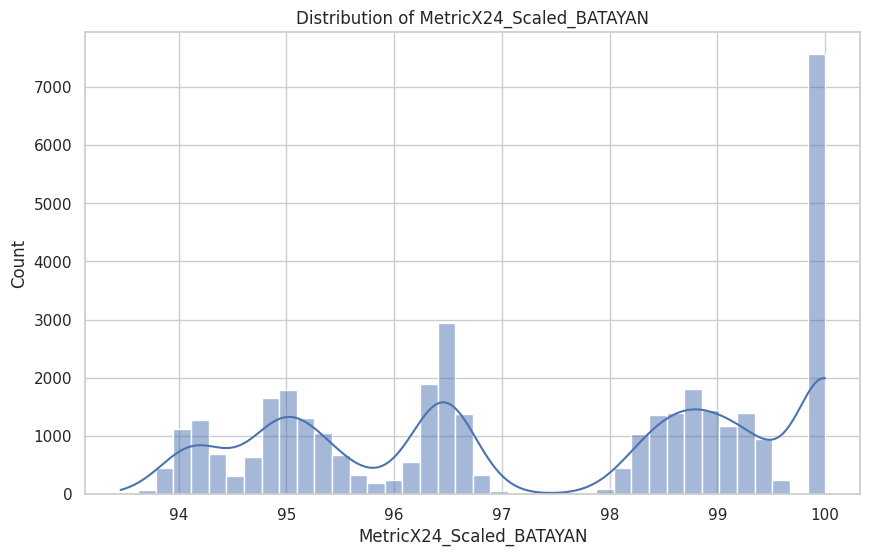

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(combined_df["MetricX24_Scaled_BATAYAN"], kde=True, bins=40)
plt.title("Distribution of MetricX24_Scaled_BATAYAN")
plt.xlabel("MetricX24_Scaled_BATAYAN")
plt.ylabel("Count")
plt.show()

In [5]:
threshold = 87.24

# Filter row with scores above threshold
filtered_df = combined_df[combined_df["MetricX24_Scaled_BATAYAN"] > threshold]

print("Filtered dataframe shape:", filtered_df.shape)

# Overall percentage retained
overall_percent = (len(filtered_df) / len(combined_df)) * 100

# Percentage per label_desc
percent_per_label = (
    filtered_df["label_desc"].value_counts() / combined_df["label_desc"].value_counts() * 100
).fillna(0)

print(f"\nOverall percentage retained (> {threshold}): {overall_percent:.2f}%\n")

print("Percentage retained per class label:")
display(percent_per_label)

Filtered dataframe shape: (37832, 6)

Overall percentage retained (> 87.24): 100.00%

Percentage retained per class label:


,count
label_desc,
sadness,100.0
joy,100.0
anxiety,100.0
stress,100.0
fear,100.0
anger,100.0
love,100.0


In [6]:
filtered_path = os.path.join(output_dir, "filtered_MTScore_above_87.24.csv")
filtered_df.to_csv(filtered_path, index=False)

print("Filtered file saved to:", filtered_path)

Filtered file saved to: /content/drive/MyDrive/AI351ProjectTest/03-Filtering/filtered_MTScore_above_87.24.csv


In [7]:
filtered_df.head()

,text,label,label_desc,translation,MetricX24_Raw,MetricX24_Scaled_BATAYAN
0,i didnt feel humiliated,0,sadness,Hindi ako nadamaang nahihiya.,0.277646,98.889417
1,i can go from feeling so hopeless to so damned...,0,sadness,Maaari akong lumipat mula sa pagiging lubos na...,0.417274,98.330905
2,im grabbing a minute to post i feel greedy wrong,3,anger,"Kukuha ako ng isang minuto para mag-post, para...",0.410044,98.359825
3,i am ever feeling nostalgic about the fireplac...,2,love,Lagi akong nakakaramdam ng pag-nostalya tungko...,0.313250,98.747002
4,i am feeling grouchy,3,anger,Masama ang pakiramdam ko.,0.476642,98.093433
